In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

(a)

In [5]:
# Compute characteristic path length of the largest connected component
def compute_characteristic_path_length(G):
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        return nx.average_shortest_path_length(subgraph)

# Calculate size of the giant cluster
def calculate_giant_cluster_size(G):
    return max(len(c) for c in nx.connected_components(G))

# Random node deletion
def random_node_removal(G, f_values):
    original_size = len(G)
    original_length = compute_characteristic_path_length(G)
    original_gc = calculate_giant_cluster_size(G)

    path_lengths = []
    giant_clusters = []

    for f in f_values:
        G_temp = G.copy()
        num_nodes_to_remove = int(f * original_size)
        nodes_to_remove = np.random.choice(list(G_temp.nodes()), num_nodes_to_remove, replace=False)
        G_temp.remove_nodes_from(nodes_to_remove)

        if len(G_temp) > 1:
            path_lengths.append(compute_characteristic_path_length(G_temp) / original_length)
            giant_clusters.append(calculate_giant_cluster_size(G_temp) / original_gc)
        else:
            path_lengths.append(0)
            giant_clusters.append(0)

    return path_lengths, giant_clusters

In [ ]:
N = 1000
m = 3
G = nx.barabasi_albert_graph(N, m)

In [ ]:
f_values = np.linspace(0, 0.9, 20)

In [ ]:
path_lengths, giant_clusters = random_node_removal(G, f_values)

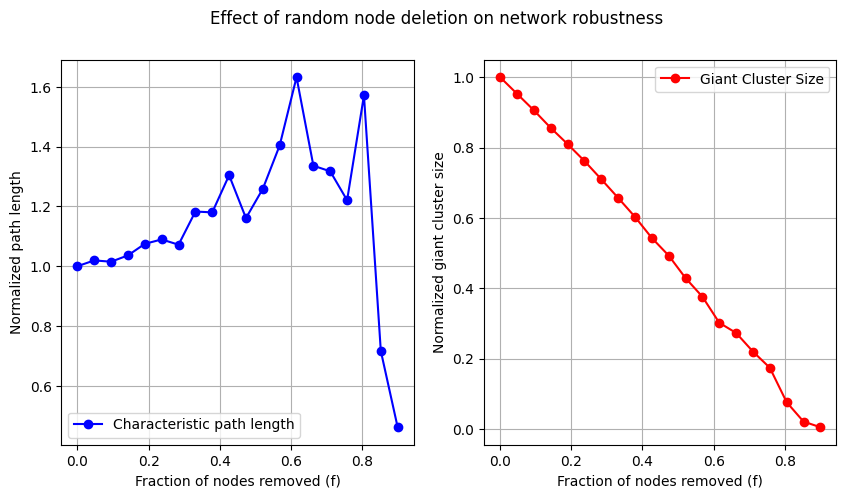

In [6]:
# Plot characteristic path length and giant cluster size
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(f_values, path_lengths, 'bo-', label="Characteristic path length")
plt.xlabel("Fraction of nodes removed (f)")
plt.ylabel("Normalized path length")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(f_values, giant_clusters, 'ro-', label="Giant Cluster Size")
plt.xlabel("Fraction of nodes removed (f)")
plt.ylabel("Normalized giant cluster size")
plt.legend()
plt.grid()

plt.suptitle("Effect of random node deletion on network robustness")
plt.show()


(b)

In [7]:
# Perform node deletion (random or targeted)
def node_removal(G, f_values, strategy):
    original_size = len(G)
    original_length = compute_characteristic_path_length(G)
    original_gc = calculate_giant_cluster_size(G)

    path_lengths = []
    giant_clusters = []

    for f in f_values:
        G_temp = G.copy()
        num_nodes_to_remove = int(f * original_size)

        if strategy == "random":
            nodes_to_remove = np.random.choice(list(G_temp.nodes()), num_nodes_to_remove, replace=False)
        elif strategy == "targeted":
            nodes_to_remove = sorted(G_temp.degree, key=lambda x: x[1], reverse=True)[:num_nodes_to_remove]
            nodes_to_remove = [node for node, _ in nodes_to_remove]

        G_temp.remove_nodes_from(nodes_to_remove)

        if len(G_temp) > 1:
            path_lengths.append(compute_characteristic_path_length(G_temp) / original_length)
            giant_clusters.append(calculate_giant_cluster_size(G_temp) / original_gc)
        else:
            path_lengths.append(0)
            giant_clusters.append(0)

    return path_lengths, giant_clusters

In [ ]:
N = 1000  # Number of nodes
p = 0.01  # Edge probability for ER network
m = 3     # Edges per new node for BA network

In [ ]:
G_er = nx.erdos_renyi_graph(N, p)
G_ba = nx.barabasi_albert_graph(N, m)

In [ ]:
f_values = np.linspace(0, 0.9, 20)

In [ ]:
er_random_path, er_random_gc = node_removal(G_er, f_values, "random")
er_targeted_path, er_targeted_gc = node_removal(G_er, f_values, "targeted")
ba_random_path, ba_random_gc = node_removal(G_ba, f_values, "random")
ba_targeted_path, ba_targeted_gc = node_removal(G_ba, f_values, "targeted")

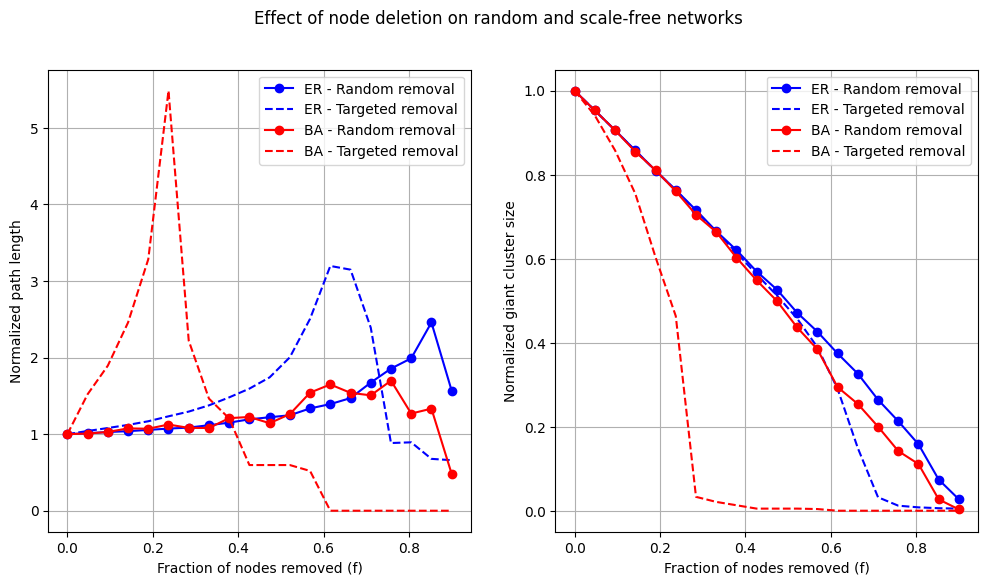

In [15]:
plt.figure(figsize=(12, 6))

# Plot characteristic path length
plt.subplot(1, 2, 1)
plt.plot(f_values, er_random_path, 'bo-', label="ER - Random removal")
plt.plot(f_values, er_targeted_path, 'b--', label="ER - Targeted removal")
plt.plot(f_values, ba_random_path, 'ro-', label="BA - Random removal")
plt.plot(f_values, ba_targeted_path, 'r--', label="BA - Targeted removal")
plt.xlabel("Fraction of nodes removed (f)")
plt.ylabel("Normalized path length")
plt.legend()
plt.grid()

# Plot giant cluster size
plt.subplot(1, 2, 2)
plt.plot(f_values, er_random_gc, 'bo-', label="ER - Random removal")
plt.plot(f_values, er_targeted_gc, 'b--', label="ER - Targeted removal")
plt.plot(f_values, ba_random_gc, 'ro-', label="BA - Random removal")
plt.plot(f_values, ba_targeted_gc, 'r--', label="BA - Targeted removal")
plt.xlabel("Fraction of nodes removed (f)")
plt.ylabel("Normalized giant cluster size")
plt.legend()
plt.grid()

plt.suptitle("Effect of node deletion on random and scale-free networks")
plt.show()


(c)

In [14]:
G_fb = nx.read_edgelist("facebook_combined.txt.gz", create_using=nx.Graph(), nodetype=int)

print(f"Number of nodes in real-world network: {G_fb.number_of_nodes()}")


Number of nodes in real-world network: 4039


Degree distribution to verify scale-free property

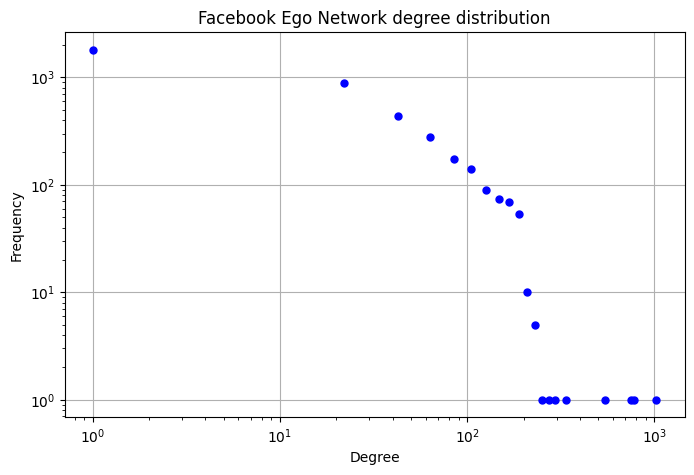

In [13]:
degree_sequence = [d for n, d in G_fb.degree()]
degree_counts, bins = np.histogram(degree_sequence, bins=50)

# Plot degree distribution
plt.figure(figsize=(8,5))
plt.loglog(bins[:-1], degree_counts, 'bo', markersize=5)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Facebook Ego Network degree distribution")
plt.grid()
plt.show()


In [ ]:
f_values = np.linspace(0, 0.9, 20)

In [ ]:
fb_random_path, fb_random_gc = node_removal(G_fb, f_values, "random")
fb_targeted_path, fb_targeted_gc = node_removal(G_fb, f_values, "targeted")

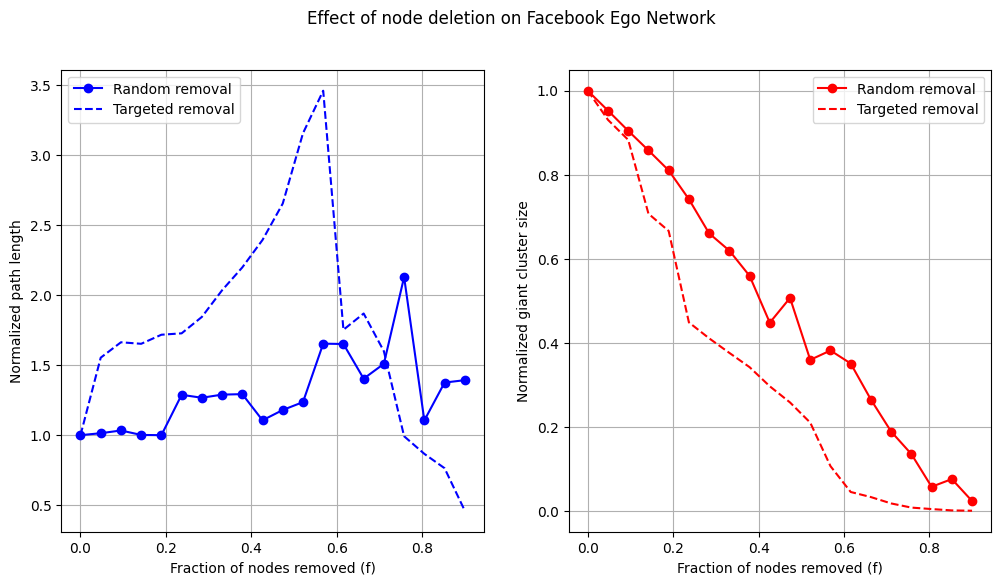

In [12]:
plt.figure(figsize=(12, 6))

# Plot characteristic path length
plt.subplot(1, 2, 1)
plt.plot(f_values, fb_random_path, 'bo-', label="Random removal")
plt.plot(f_values, fb_targeted_path, 'b--', label="Targeted removal")
plt.xlabel("Fraction of nodes removed (f)")
plt.ylabel("Normalized path length")
plt.legend()
plt.grid()

# Plot giant cluster size
plt.subplot(1, 2, 2)
plt.plot(f_values, fb_random_gc, 'ro-', label="Random removal")
plt.plot(f_values, fb_targeted_gc, 'r--', label="Targeted removal")
plt.xlabel("Fraction of nodes removed (f)")
plt.ylabel("Normalized giant cluster size")
plt.legend()
plt.grid()

plt.suptitle("Effect of node deletion on Facebook Ego Network")
plt.show()


(d)

# **Comparison with Albert et al., Nature, 406, 378 (2000)**  

Albert et al. studied the resilience of **random** vs. **scale-free networks** under node deletion and found that:  
1. **Random networks** degrade **gradually** under both random and targeted attacks.  
2. **Scale-free networks** are **highly robust to random failures** but **extremely vulnerable to targeted attacks**.  

---

## **(i) Characteristic path length**  

### **Observations from the plot :**  
- **Random removal (solid blue line):** Characteristic path length \(L\) **remains stable** and fluctuates slightly.  
- **Targeted removal (dashed blue line):** Characteristic path length \(L\) **increases sharply**, then collapses as the network fragments.  

### **Comparison with Albert et al. :**  
- Albert et al. showed that in **scale-free networks**, random node deletion **does not significantly increase** the characteristic path length, which agrees with our result.  
- However, **targeted attacks cause a sudden increase in characteristic path length \(L\)** before network fragmentation, matching Albert et al.'s findings.  

---

## **(ii) Giant cluster size**  

### **Observations from the plot :**  
- **Random removal (solid red line):** The giant component size \(S\) **declines gradually**.  
- **Targeted removal (dashed red line):** The decline giant component size \(S\) is **much steeper**, breaking the network into small disconnected components.  

### **Comparison with Albert et al. :**  
- Albert et al. found that in scale-free networks, random removal **does not significantly reduce** the giant cluster until a large fraction \(f\) of nodes are removed, which agrees with our result.  
- **Targeted removal quickly destroys the giant cluster**, which is consistent with their findings.  

---

The observations verify Albert et al.'s conclusion that **scale-free networks are robust against random failures but vulnerable to targeted attacks**.  
**Targeted attacks disrupt the network much faster** than random failures, showing the importance of hub nodes.